In [1]:
ETA_REFUSAL_TABLE = {
    2.5: 10.85106,
    7.5: 12.12766,
    12.5: 11.48936,
    17.5: 10.42553,
    22.5: 10.85106,
    27.5: 12.76596,
    32.5: 15.10638,
    37.5: 16.17021,
    42.5: 18.7234,
    47.5: 13.19149,
    52.5: 21.06383,
    57.5: 6.38298
}

PICK_DISTANCE_REFUSAL_TABLE = {
    0.1: 23.61992,
    0.3: 24.07056,
    0.5: 26.41302,
    0.7: 23.07046,
    0.9: 21.41398,
    1.1: 18.49341,
    1.3: 15.36233,
    1.5: 9.70594,
    1.7: 13.52015,
    1.9: 10.39192,
    2.1: 5.78814,
    2.3: 8.76026,
    2.5: 5.84161,
    2.7: 2.92104,
    2.9: 3.78891,
    3.1: 7.8165,
    3.3: 12.89765,
    3.5: 1.97537,
    3.7: 14.21424,
    3.9: 2.03074
}
ON_HAND_ORDER_REFUSAL_TABLE = {
    0.0: 29.74526,
    1.0: 13.82838,
    2.0: 11.07474,
    3.0: 12.20765,
    4.0: 9.45641,
    5.0: 12.31596,
    6.0: 20.35544,
    7.0: 14.15012,
    8.0: 37.29771
}

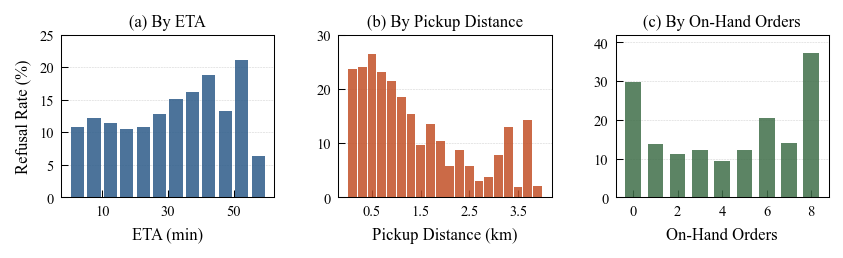

Saved: refusal_rate_analysis.pdf / .png


In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import numpy as np

# Paper style font setup
font_path = '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf'
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = font_prop.get_name()
mpl.rcParams['font.family'] = 'Times New Roman'

# Paper style settings (matching ablation.ipynb)
mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'text.usetex': False,
    'mathtext.fontset': 'stix',
})

# Colors
C_ETA = '#2c5b89'      # Blue
C_DIST = '#c25027'     # Orange  
C_ONHAND = '#3f6e49'   # Green

# Create 1x3 figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(5.5, 1.6))

# ===== Plot 1: ETA Refusal Rate =====
eta_bins = list(ETA_REFUSAL_TABLE.keys())
eta_rates = list(ETA_REFUSAL_TABLE.values())

ax1.bar(eta_bins, eta_rates, width=4, color=C_ETA, edgecolor='none', alpha=0.85)
ax1.set_xlabel('ETA (min)')
ax1.set_ylabel('Refusal Rate (%)')
ax1.set_title('(a) By ETA', fontweight='bold', pad=4)
ax1.yaxis.grid(True, linestyle='--', linewidth=0.25, alpha=0.6)
ax1.set_axisbelow(True)
ax1.set_xticks([10, 30, 50])
ax1.set_ylim(0, 25)
for spine in ax1.spines.values():
    spine.set_linewidth(0.5)

# ===== Plot 2: Pickup Distance Refusal Rate =====
dist_bins = list(PICK_DISTANCE_REFUSAL_TABLE.keys())
dist_rates = list(PICK_DISTANCE_REFUSAL_TABLE.values())

ax2.bar(dist_bins, dist_rates, width=0.18, color=C_DIST, edgecolor='none', alpha=0.85)
ax2.set_xlabel('Pickup Distance (km)')
ax2.set_title('(b) By Pickup Distance', fontweight='bold', pad=4)
ax2.yaxis.grid(True, linestyle='--', linewidth=0.25, alpha=0.6)
ax2.set_axisbelow(True)
ax2.set_xticks([0.5, 1.5, 2.5, 3.5])
ax2.set_ylim(0, 30)
for spine in ax2.spines.values():
    spine.set_linewidth(0.5)

# ===== Plot 3: On-Hand Orders Refusal Rate =====
onhand_bins = list(ON_HAND_ORDER_REFUSAL_TABLE.keys())
onhand_rates = list(ON_HAND_ORDER_REFUSAL_TABLE.values())

ax3.bar(onhand_bins, onhand_rates, width=0.7, color=C_ONHAND, edgecolor='none', alpha=0.85)
ax3.set_xlabel('On-Hand Orders')
ax3.set_title('(c) By On-Hand Orders', fontweight='bold', pad=4)
ax3.yaxis.grid(True, linestyle='--', linewidth=0.25, alpha=0.6)
ax3.set_axisbelow(True)
ax3.set_xticks([0, 2, 4, 6, 8])
ax3.set_ylim(0, 42)
for spine in ax3.spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout(pad=0.3)
fig.subplots_adjust(wspace=0.3)

plt.savefig('refusal_rate_analysis.pdf', bbox_inches='tight', pad_inches=0.02)
plt.savefig('refusal_rate_analysis.png', bbox_inches='tight', pad_inches=0.02)
plt.show()
print('Saved: refusal_rate_analysis.pdf / .png')